In [11]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'    # GPU No.
from sampler.utils import *
#print(dir())
import importlib
import sampler.utils
importlib.reload(sampler.utils)
from trainer.utils import restore_checkpoint
import torch
import torch.nn as nn
import json
from collections import namedtuple
from tqdm import tqdm
from models import get_model, get_ema
from sampler import VESDE
import numpy as np
from einops import rearrange

data_name = '2DSound'
version = 'v0'       
opt_path = 'results/2DSound_v0/config.json'
with open(opt_path, 'r', encoding='utf-8') as f:
    opt = json.load(f)
    opt['num_channels'] = opt['num_components'] + opt['num_conditions']
OPT_class = namedtuple('OPT_class', opt.keys())
opt = OPT_class(**opt)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load pretrained model

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = get_model(opt)
#net = nn.DataParallel(net)
net.to(device)
ema = get_ema(net.parameters(), decay=opt.ema_rate)
optimizer = torch.optim.Adam(net.parameters(), lr=opt.lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
state = dict(optimizer=optimizer, model=net, ema=ema, epoch=0, iteration=0, loss_train=[])

ckpt_path = opt.results_path + '/checkpoint_200.pth'

state = restore_checkpoint(ckpt_path, state, device)
net = state['model']
ema = state['ema']
ema.copy_to(net.parameters())
print('Model loaded from epoch', state['epoch'])

Model loaded from epoch 200


In [13]:
class DataScalar:
    def __init__(self, mean, std, device='cpu'):
        self.mean_np = mean
        self.std_np = std
        self.device = device
        self.mean_torch = torch.tensor(mean).float().to(device)
        self.std_torch = torch.tensor(std).float().to(device)
        if self.mean_torch.ndim == 5:
            self.mean_torch = self.mean_torch.permute(0, 1, 4, 2, 3)
            self.std_torch = self.std_torch.permute(0, 1, 4, 2, 3)

    def normalize(self, x_np):
        mean_t = self.mean_np.transpose(0, 1, 4, 2, 3)
        std_t = self.std_np.transpose(0, 1, 4, 2, 3)
        return (x_np - mean_t) / std_t

    def unnormalize(self, x):
        if x.device != self.mean_torch.device:
            self.mean_torch = self.mean_torch.to(x.device)
            self.std_torch = self.std_torch.to(x.device)
        return x * self.std_torch + self.mean_torch

def select_test_sample_by_freq(data_raw):
    freq_list = [125, 135, 175, 225, 275, 325, 375, 415, 425]
    print("-" * 40)
    try:
        user_input = input(f"Please enter the target frequency (for example, 175), and press Enter to select the first option by default:")
        if not user_input.strip():
            target_idx = 0
        else:
            diff = [abs(f - float(user_input)) for f in freq_list]
            target_idx = diff.index(min(diff))
    except:
        target_idx = 0
        print("Invalid input. Defaulting to Index 0.")
    return data_raw[target_idx:target_idx+1]

In [14]:
import sys
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

try:
    from fno import FNO2d
except ImportError:
    current_dir = os.getcwd()
    model_dir = os.path.join(current_dir, 'models')
    sys.path.append(model_dir) 
    try:
        from fno import FNO2d
    except ImportError:
        print("Warning: Could not import FNO2d. FNO generation might fail.")

# ================= [ADD] LNO Import Logic =================
try:
    from lno import LNO2d
except ImportError:
    current_dir = os.getcwd()
    model_dir = os.path.join(current_dir, 'models')
    sys.path.append(model_dir) 
    try:
        from lno import LNO2d
    except ImportError:
        print("Warning: Could not import LNO2d. LNO generation might fail.")

class LNOConfig:
    MODES = 16
    WIDTH = 8
    NUM_CHANNELS = 3
    SEQUENCE_LENGTH = 10 
    INPUT_RES = 6
    OUTPUT_RES = 64
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    MODEL_PATH = '/results_LNO/lno_reconstruction_2x.pth'


class FNOConfig:
    MODES = 16
    WIDTH = 64
    NUM_CHANNELS = 3
    SEQUENCE_LENGTH = 10 
    INPUT_RES = 6
    OUTPUT_RES = 64
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    MODEL_PATH = '/results_FNO/fno_reconstruction_2x.pth'

def get_grid(shape, device):
    batchsize, size_x, size_y = shape[0], shape[1], shape[2]
    gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
    gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
    gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
    gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
    return torch.cat((gridx, gridy), dim=-1).to(device)

def load_fno_model(config, path_override=None):
    model = FNO2d(
        num_channels=config.NUM_CHANNELS,
        out_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        modes1=config.MODES,
        modes2=config.MODES,
        width=config.WIDTH,
        initial_step=config.SEQUENCE_LENGTH
    ).to(config.DEVICE)
    
    path = path_override if path_override else config.MODEL_PATH
    if not os.path.exists(path):
        path = os.path.join('results', config.MODEL_PATH)
    
    if os.path.exists(path):
        state_dict = torch.load(path, map_location=config.DEVICE)
        model.load_state_dict(state_dict)
        print(f"FNO Model loaded from {path}")
    else:
        print(f"Warning: FNO Model not found at {path}")
    
    model.eval()
    return model

def load_lno_model(config, path_override=None):
    tx = torch.linspace(0, 1, config.OUTPUT_RES).unsqueeze(0).to(config.DEVICE)
    ty = torch.linspace(0, 1, config.OUTPUT_RES).unsqueeze(0).to(config.DEVICE)

    model = LNO2d(
        in_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        out_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        width=config.WIDTH,
        modes1=config.MODES,
        modes2=config.MODES,
        tx=tx, 
        ty=ty
    ).to(config.DEVICE)
    
    path = path_override if path_override else config.MODEL_PATH
    if not os.path.exists(path):
        path = os.path.join('results', config.MODEL_PATH) # Fallback check
    
    if os.path.exists(path):
        state_dict = torch.load(path, map_location=config.DEVICE)
        model.load_state_dict(state_dict)
        print(f"LNO Model loaded from {path}")
    else:
        print(f"Warning: LNO Model not found at {path}")
    
    model.eval()
    return model

# Load test data

In [15]:
data_test_path = "/media/zzy/raid5/anechoic_high_prec_dataset_last700_test_2.npy"
scalar_path = opt.results_path + '/scalar.npy'
data_raw = np.load(data_test_path) # (9, 700, 64, 64, 3)

scalar_data = np.load(scalar_path, allow_pickle=True)
mean_val, std_val = (scalar_data[0], scalar_data[1]) if isinstance(scalar_data, np.ndarray) else (scalar_data[0], scalar_data[1])
scaler = DataScalar(mean_val, std_val, device=device)

x_test_raw = select_test_sample_by_freq(data_raw) 
x_test = x_test_raw.transpose(0, 1, 4, 2, 3)
print(f"Sample Shape (Model Input): {x_test.shape}")

_, z = np.meshgrid(np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False),
                   np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False), indexing='ij')
#[125,135,175,225,275,325,375,415,425]

----------------------------------------
Sample Shape (Model Input): (1, 700, 3, 64, 64)


# Load test data

In [ ]:
m           =   2
T           =   opt.num_frames
T_prime     =   100
B_batch     =   int(np.ceil((T_prime-m) / (T - m))) 
T_prime     =   B_batch * (T - m) + m
n_samples   =   1

seed_samples = 1
rnd = np.random.RandomState(seed_samples)

t_start = 0 
samples = x_test[:, t_start:t_start+T_prime] 
print(f"Target Shape: {samples.shape}")

samples_scale_all = scaler.normalize(samples)


noise_ratio = 0.01
noise = rnd.randn(*samples_scale_all.shape)
samples_scale_all = samples_scale_all + noise_ratio * noise
print(f"Applied {noise_ratio*100}% Gaussian noise to normalized samples.")


print(samples_scale_all.shape)

Target Shape: (1, 106, 3, 64, 64)
Applied 0% Gaussian noise to normalized samples.
(1, 106, 3, 64, 64)


# Reconstruction

In [ ]:
outer_loop = 100  
denoising_steps1 = outer_loop
denoising_steps2 = 100

seed_sample = 123
cof = 5e-8
obs_type = 'regular'
scale =  6       

alpha_case = 0.4
beta = 0.4
gamma = 0.5

sde = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=outer_loop)
sde1 = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=denoising_steps1)
sde2 = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=denoising_steps2)
net.eval()
reap_fn = lambda x, num: torch.stack([x for _ in range(num)])

setup_seed(seed_sample)

with torch.no_grad():
    if obs_type.lower() == 'random':
        T_prime_y = T_prime
        mask = np.zeros([opt.num_components+opt.num_conditions, opt.image_size, opt.image_size])
        mask[:opt.num_components] = mask_gen([1, opt.image_size, opt.image_size], scale, seed=seed_samples)
        mask_torch = torch.from_numpy(mask).to(device)
        transform_gen = transform = lambda x:x[:, :T_prime_y]*mask[np.newaxis, np.newaxis] if isinstance(x, np.ndarray) else x[:, :T_prime_y]*mask_torch[None, None].to(x.device)
        sparsity = scale            
    elif obs_type.lower() == 'regular':
        T_prime_y = T_prime
        transform_gen = transform = lambda x:x[:, :T_prime_y, :opt.num_components, ::scale, ::scale]     
        sparsity = 1-1/scale**2     
    elif obs_type.lower() == 'forecast':
        T_prime_y = 0
        transform_gen = transform = lambda x:x[:, :scale]
        sparsity = 1-scale/T        

    alpha = alpha_case/np.sqrt(1-sparsity)
    y = transform_gen(samples_scale_all)
    print(f"Observation shape (Normalized): {y.shape}")

    latent_mask = torch.ones([T, 1, 1, 1]).float().to(device)
    obs_mask = torch.zeros([T, 1, 1, 1]).float().to(device)
    frame_indices = torch.arange(T).to(device)
    
    net_fn = lambda x, t: net(x, x0=x, timesteps=t, 
                              latent_mask=reap_fn(latent_mask, len(x)), 
                              obs_mask=reap_fn(obs_mask, len(x)), 
                              frame_indices=reap_fn(frame_indices, len(x)))[0]

    x_inpainted = s3gm_sample_2d(
        opt, net_fn, sde, y, transform_gen,
        alpha=0.5/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
        T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
        corrector=NoneCorrector, n_steps=0,
        snr=0.128, device=device, dtype='float', eps=1e-12,
        probability_flow=False, continuous=True
    )
    x_pred = x_inpainted.copy() 
    
    setup_seed(seed_sample)

    print(">>> Sampling ISS...")
    x_inpainted1 = MRSM_sample_2d_ISS_2dsound(
        opt, net_fn, sde1, y, transform_gen,
        alpha=0.5/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
        T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
        corrector=NoneCorrector, n_steps=0, eta=0, 
        reg_coef_pa = 10*T_prime, reg_coef_ar = 1e2,
        denoising_steps=denoising_steps1, snr=0.128, device=device, dtype='float', eps=1e-12,
        probability_flow=False, continuous=True
    )
    x_pred1 = x_inpainted1.copy()
    
    setup_seed(seed_sample)

    print(">>> Sampling ISS Res (Physics)...")
    x_inpainted2 = MRSM_sample_2d_ISS_2dsound_res(
        opt, net_fn, sde2, y, transform_gen,
        alpha=1/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
        T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
        corrector=NoneCorrector, n_steps=0, eta=0, 
        use_residual_objective=False,
        reg_coef_pa = 10*T_prime, reg_coef_ar = 1e2,
        denoising_steps=denoising_steps2, snr=0.128, device=device, dtype='float', eps=1e-12,
        probability_flow=False, continuous=True,
        data_scalar=scaler.unnormalize,
        physics_start_step=100,  
        reg_coef_wave=1 * cof,     
        reg_coef_cont=1 * cof,    
        reg_coef_euler=1 * cof,    
        physics_c=343.0,        
        physics_rho0=1.21,      
        physics_dt=1e-4,        
        physics_dx=1/21,        
        physics_dy=1/21
    )
    x_pred2 = x_inpainted2.copy()

    print(">>> Running LNO generation (2D Sound - Normalized Input)...")
    try:
        lno_cfg = LNOConfig()
        model_path = '/results_LNO_2dsound/lno_2dsound_reconstruction_6x.pth'
        lno_model = load_lno_model(lno_cfg, path_override=model_path)
        samples_norm_lno = scaler.normalize(samples[:, :, :opt.num_components])
        gt_input_lno = torch.tensor(samples_norm_lno, dtype=torch.float).to(lno_cfg.DEVICE)
        
        SEQ_LEN = lno_cfg.SEQUENCE_LENGTH
        TARGET_LEN = T_prime
        num_chunks = int(np.ceil(TARGET_LEN / SEQ_LEN))
        
        pred_lno_list = []
        
        for i in range(num_chunks):
            chunk_start = i * SEQ_LEN
            chunk_end = chunk_start + SEQ_LEN
            actual_end = min(chunk_end, gt_input_lno.shape[1])
            
            chunk_data = gt_input_lno[:, chunk_start:actual_end, ...]
            
            # Padding
            curr_len = chunk_data.shape[1]
            pad_len = 0
            if curr_len < SEQ_LEN:
                pad_len = SEQ_LEN - curr_len
                B, _, C, H, W = chunk_data.shape
                padding = torch.zeros(B, pad_len, C, H, W).to(lno_cfg.DEVICE)
                chunk_data_padded = torch.cat([chunk_data, padding], dim=1)
            else:
                chunk_data_padded = chunk_data
            
            x_low = chunk_data_padded[:, :, :, ::lno_cfg.INPUT_RES, ::lno_cfg.INPUT_RES]
            
            B_sz, T_ch, C_ch, H_l, W_l = x_low.shape
            x_in = x_low.reshape(B_sz * T_ch, C_ch, H_l, W_l)
            x_in = F.interpolate(x_in, size=(lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES), mode='bilinear', align_corners=True)
            
            x_in_lno = x_in.reshape(B_sz, T_ch, C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            x_in_lno = x_in_lno.reshape(B_sz, T_ch * C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            
            out_lno = lno_model(x_in_lno) 
            
            out_lno = out_lno.reshape(B_sz, T_ch, C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            
            if pad_len > 0:
                out_lno = out_lno[:, :-pad_len, ...]
            
            pred_lno_list.append(out_lno)
            
        pred_seq_lno = torch.cat(pred_lno_list, dim=1) # Shape: (B, T, C, H, W)
        pred_lno_phys = scaler.unnormalize(pred_seq_lno)

        x_pred3_core = pred_lno_phys.detach().cpu().numpy() # [Result is Physical]

        

        x_pred3 = np.zeros_like(x_pred) 
        x_pred3[:, :, :opt.num_components] = x_pred3_core
        if x_pred.shape[2] > opt.num_components:
            x_pred3[:, :, opt.num_components:] = samples[:, :x_pred3.shape[1], opt.num_components:]
            
    except Exception as e:
        print(f"LNO inference failed: {e}")
        import traceback
        traceback.print_exc()
        x_pred3 = np.zeros_like(x_pred)


    print(">>> Running FNO generation (2D Sound - Raw Physics)...")
    try:
        fno_cfg = FNOConfig()
        model_path = '/results_FNO_2dsound/fno_2dSound_reconstruction_6x.pth'
        fno_model = load_fno_model(fno_cfg, path_override=model_path)
        
        samples_norm = scaler.normalize(samples[:, :, :opt.num_components])
        gt_input = torch.tensor(samples_norm, dtype=torch.float).permute(0, 1, 3, 4, 2).to(fno_cfg.DEVICE)
        
        SEQ_LEN = fno_cfg.SEQUENCE_LENGTH
        TARGET_LEN = T_prime
        num_chunks = int(np.ceil(TARGET_LEN / SEQ_LEN))
        
        pred_seq_list = []
        
        for i in range(num_chunks):
            chunk_start = i * SEQ_LEN
            chunk_end = chunk_start + SEQ_LEN
            actual_end = min(chunk_end, gt_input.shape[1])
            
            chunk_data = gt_input[:, chunk_start:actual_end, ...]
            
            # Padding
            curr_len = chunk_data.shape[1]
            pad_len = 0
            if curr_len < SEQ_LEN:
                pad_len = SEQ_LEN - curr_len
                B, _, H, W, C = chunk_data.shape
                padding = torch.zeros(B, pad_len, H, W, C).to(fno_cfg.DEVICE)
                chunk_data_padded = torch.cat([chunk_data, padding], dim=1)
            else:
                chunk_data_padded = chunk_data
            
            x_low = chunk_data_padded[:, :, ::fno_cfg.INPUT_RES, ::fno_cfg.INPUT_RES, :]
            B_sz, T_ch, H_l, W_l, C_ch = x_low.shape
            
            x_in = x_low.reshape(B_sz * T_ch, H_l, W_l, C_ch).permute(0, 3, 1, 2)
            x_in = F.interpolate(x_in, size=(fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES), mode='bilinear', align_corners=True)
            
            x_in = x_in.reshape(B_sz, T_ch, C_ch, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES).permute(0, 3, 4, 1, 2).reshape(B_sz, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES, T_ch * C_ch)
            
            grid = get_grid(x_in.shape, fno_cfg.DEVICE)
            out = fno_model(x_in, grid).squeeze(-2)
            
            out = out.view(B_sz, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES, T_ch, C_ch).permute(0, 3, 1, 2, 4)
            if pad_len > 0:
                out = out[:, :-pad_len, ...]
            pred_seq_list.append(out)
            
        pred_seq = torch.cat(pred_seq_list, dim=1) 
        pred_seq_permuted = pred_seq.permute(0, 1, 4, 2, 3)
        pred_phys = scaler.unnormalize(pred_seq_permuted)
        
        x_pred4_core = pred_phys.detach().cpu().numpy()
        
        x_pred4 = np.zeros_like(x_pred)
        x_pred4[:, :, :opt.num_components] = x_pred4_core
        if x_pred.shape[2] > opt.num_components:
            x_pred4[:, :, opt.num_components:] = samples[:, :x_pred4.shape[1], opt.num_components:]

    except Exception as e:
        print(f"FNO inference failed: {e}")
        import traceback
        traceback.print_exc()
        x_pred4 = np.zeros_like(x_pred)

def unnorm_tensor(x_numpy):
    if x_numpy is None: return None
    t = torch.tensor(x_numpy).float().to(device)
    return scaler.unnormalize(t).detach().cpu().numpy()

print("-" * 40)
print(">>> Processing Evaluation Metrics (Channel-wise Averaged)...")

phys_pred  = unnorm_tensor(x_pred)
phys_pred1 = unnorm_tensor(x_pred1)
phys_pred2 = unnorm_tensor(x_pred2)

phys_pred3 = x_pred3 
phys_pred4 = x_pred4

phys_gt = samples[0] 

def calc_and_print_fair_metrics(method_name, pred_batch, gt):
    if pred_batch is None:
        return

    # pred_batch: (1, T, C, H, W) -> pred: (T, C, H, W)
    pred = pred_batch[0]
    err_p = cal_rmse(gt[:, 0:1], pred[:, 0:1], normalize=True)
    mean_p = np.mean(err_p)
    err_vx = cal_rmse(gt[:, 1:2], pred[:, 1:2], normalize=True)
    mean_vx = np.mean(err_vx)
    err_vy = cal_rmse(gt[:, 2:3], pred[:, 2:3], normalize=True)
    mean_vy = np.mean(err_vy)
    
    mean_fair = (mean_p + mean_vx + mean_vy) / 3.0
    
    print(f"{method_name:<20} | {mean_fair:<12.5f} | {mean_p:<10.5f} | {mean_vx:<10.5f} | {mean_vy:<10.5f}")

print("-" * 75)
print(f"{'Method':<20} | {'Mean(Avg)':<12} | {'P(RMSE)':<10} | {'Vx(RMSE)':<10} | {'Vy(RMSE)':<10}")
print("-" * 75)

calc_and_print_fair_metrics('SDE', phys_pred, phys_gt)
calc_and_print_fair_metrics('ISS', phys_pred1, phys_gt)
calc_and_print_fair_metrics('PI-ISS', phys_pred2, phys_gt)
calc_and_print_fair_metrics('LNO', phys_pred3, phys_gt)
calc_and_print_fair_metrics('FNO', phys_pred4, phys_gt)

print("-" * 75)
print("Note: Mean(Avg) = (P + Vx + Vy) / 3. Equal weight for all channels.")
torch.cuda.empty_cache()

Observation shape (Normalized): (1, 106, 3, 11, 11)
>>> Sampling Baseline (S3GM)...


loss total: 4.10832e+02 | loss obs.: 2.59589e+01 | loss consis.: 3.84873e+02: 100%|██████████| 100/100 [00:11<00:00,  8.47it/s]


>>> Sampling ISS...


SDE | loss total: 7.49381e+02 | loss obs.: 3.45615e+01 | loss consis.: 1.94795e+02 | reg_loss.: 5.20024e+02: 100%|██████████| 100/100 [00:11<00:00,  8.58it/s]


>>> Sampling ISS Res (Physics)...


SDE | loss total: 6.33484e+02 | loss obs.: 3.97648e+01 | loss consis.: 4.95593e+01 | reg_loss.: 5.15954e+02 | loss_phy: 2.82052e+04: 100%|██████████| 100/100 [00:12<00:00,  8.19it/s]


>>> Running LNO generation (2D Sound - Normalized Input)...
LNO Model loaded from /home/zzy/pythonprojects/S3GM/S3GM/S3GM-main/S3GM-main/results_LNO_2dsound/lno_2dsound_reconstruction_6x.pth
>>> Running FNO generation (2D Sound - Raw Physics)...
FNO Model loaded from /home/zzy/pythonprojects/S3GM/S3GM/S3GM-main/S3GM-main/results_FNO_2dsound/fno_2dSound_reconstruction_6x.pth
----------------------------------------
>>> Processing Evaluation Metrics (Channel-wise Averaged)...
---------------------------------------------------------------------------
Method               | Mean(Avg)    | P(RMSE)    | Vx(RMSE)   | Vy(RMSE)  
---------------------------------------------------------------------------
SDE                  | 0.11498      | 0.11383    | 0.11223    | 0.11887   
ISS                  | 0.06445      | 0.06342    | 0.06066    | 0.06927   
PI-ISS               | 0.03282      | 0.03143    | 0.02984    | 0.03719   
LNO                  | 0.30729      | 0.27075    | 0.29102    | 0.360

# Visualization

Intensity Magnitude Max (98%): 6.8261e-04 W/m^2


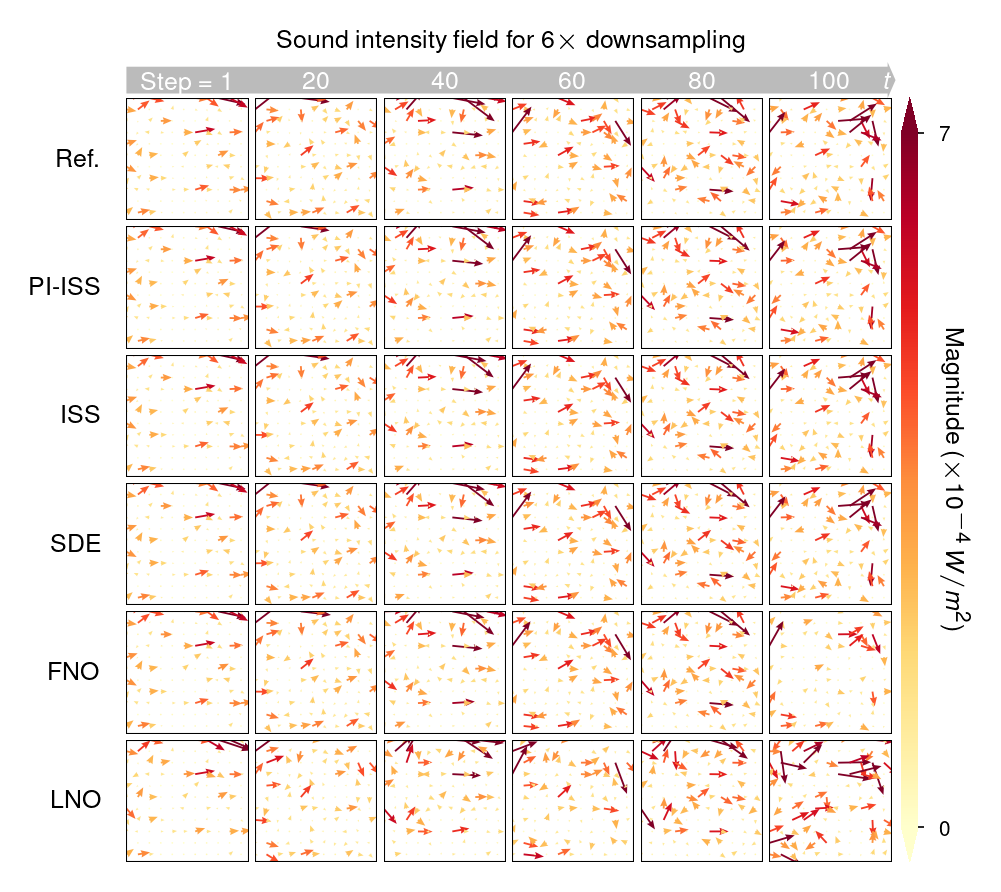

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import os
import matplotlib as mpl
import matplotlib.ticker as ticker


TARGET_WIDTH_INCH = 7 / 2.54  
DPI_FOR_PUBLICATION = 300 
UNIFORM_FONT_SIZE = 6     

try:
    mpl.rcParams['text.usetex'] = True
    
    mpl.rcParams['text.latex.preamble'] = r'''
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath} 
        \sansmath
    '''
    
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
    
except:
    print("Warning: LaTeX not found, falling back to standard rendering.")
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['font.family'] = 'sans-serif'

mpl.rcParams['axes.linewidth'] = 0.5      
mpl.rcParams['xtick.major.width'] = 0.4   
mpl.rcParams['ytick.major.width'] = 0.4
mpl.rcParams['font.size'] = UNIFORM_FONT_SIZE
mpl.rcParams['axes.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['xtick.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['ytick.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['legend.fontsize'] = UNIFORM_FONT_SIZE

def plot_intensity_field(ix_fields, iy_fields, row, col, row_labels=None, col_labels=None, 
                         title=None, cbar_label="Intensity Magnitude", 
                         dpi=DPI_FOR_PUBLICATION, mag_max=None, save_fig=None):

    SCALE_FACTOR = TARGET_WIDTH_INCH / (col * 1.5 + 2.5)
    
    figsize_width = TARGET_WIDTH_INCH 
    figsize_height = (row * 1.5 + 1.8) * SCALE_FACTOR * 1.2 
    
    fig, axes = plt.subplots(row, col, figsize=(figsize_width, figsize_height), dpi=dpi)
    
    plt.subplots_adjust(left=0.08 * SCALE_FACTOR * 2.0, 
                        right=1.0 - (0.15 * SCALE_FACTOR), 
                        top=0.88, 
                        bottom=0.06, 
                        wspace=0.05, hspace=0.05)
    
    # Reshape if necessary
    if ix_fields.ndim == 3:
        ix_fields = ix_fields.reshape(row, col, *ix_fields.shape[1:])
        iy_fields = iy_fields.reshape(row, col, *iy_fields.shape[1:])
    
    QUIVER_STEP = 6
    
    H, W = ix_fields.shape[2], ix_fields.shape[3]
    X, Y = np.meshgrid(np.arange(W), np.arange(H))
    
    if mag_max is None:
        mag_all = np.sqrt(ix_fields**2 + iy_fields**2)
        mag_max = np.percentile(mag_all, 98) 
    
    if mag_max == 0:
        exponent = 0
        nice_max = 0.5
    else:
        exponent = int(np.floor(np.log10(mag_max)))
        mantissa = mag_max / (10**exponent)
        nice_mantissa = np.ceil(mantissa)
        nice_max = nice_mantissa * (10**exponent)

    norm = mcolors.Normalize(vmin=0, vmax=nice_max)
    
    scale_val = nice_max * 5

    Q = None 

    for i in range(row):
        for j in range(col):
            Ix = ix_fields[i, j]
            Iy = iy_fields[i, j]
            ax = axes[i, j]
            
            magnitude = np.sqrt(Ix**2 + Iy**2)
            X_sub = X[::QUIVER_STEP, ::QUIVER_STEP]
            Y_sub = Y[::QUIVER_STEP, ::QUIVER_STEP]
            U_sub = Ix[::QUIVER_STEP, ::QUIVER_STEP]
            V_sub = Iy[::QUIVER_STEP, ::QUIVER_STEP]
            C_sub = magnitude[::QUIVER_STEP, ::QUIVER_STEP]
            Q = ax.quiver(X_sub, Y_sub, U_sub, V_sub, C_sub,
                          cmap='YlOrRd', norm=norm, 
                          scale=scale_val, scale_units='width', 
                          angles='xy', width=0.015, headwidth=4, headlength=5)
            
            ax.set_xlim(0, W)
            ax.set_ylim(H, 0)
            ax.set_aspect('equal')
            ax.axis('off') 
            rect = patches.Rectangle((0, 0), W, H, linewidth=0.5, edgecolor='black', facecolor='none', transform=ax.transData)
            ax.add_patch(rect)
            
            if j == 0 and row_labels is not None and i < len(row_labels):
                ax.text(-0.2, 0.5, row_labels[i], 
                        transform=ax.transAxes, 
                        fontsize=UNIFORM_FONT_SIZE, 
                        va='center', 
                        ha='right',
                       )

    if col_labels is not None:
        bbox0 = axes[0, 0].get_position()
        bbox_last = axes[0, -1].get_position()
        
        arrow_x_start = bbox0.x0
        arrow_x_end = bbox_last.x1 + 0.02 * SCALE_FACTOR 
        
        arrow_y = bbox0.y1 + 0.02 * SCALE_FACTOR
        arrow_h = 0.12 * SCALE_FACTOR

        head_len = 0.04 * SCALE_FACTOR
        rect_x_end = arrow_x_end - head_len
        
        verts = [
            (arrow_x_start, arrow_y),
            (rect_x_end, arrow_y),
            (rect_x_end, arrow_y - 0.005),
            (arrow_x_end, arrow_y + arrow_h/2),
            (rect_x_end, arrow_y + arrow_h + 0.005),
            (rect_x_end, arrow_y + arrow_h),
            (arrow_x_start, arrow_y + arrow_h),
            (arrow_x_start, arrow_y)
        ]
        
        poly = patches.Polygon(verts, transform=fig.transFigure, 
                               facecolor='#bbbbbb', edgecolor='none', zorder=0)
        fig.add_artist(poly)
        
        for idx, label in enumerate(col_labels):
            ax_curr = axes[0, idx]
            bbox = ax_curr.get_position()
            center_x = (bbox.x0 + bbox.x1) / 2
            center_y = arrow_y + arrow_h / 2 - 0.002
            text_str = (f"Step = {label}" if idx == 0 else label)
            
            fig.text(center_x, center_y, text_str, 
                     fontsize=UNIFORM_FONT_SIZE, 
                     color='white', 
                     ha='center', va='center')

        fig.text(arrow_x_end - 0.04 * SCALE_FACTOR, center_y, r"$t$", 
                 fontsize=UNIFORM_FONT_SIZE, 
                 color='white', 
                 ha='center', va='center')

        if title:
            title_x = (arrow_x_start + arrow_x_end) / 2
            title_y = arrow_y + arrow_h + 0.015
            safe_title = title.replace('×', r'$\times$')
            fig.text(title_x, title_y, 
                     safe_title, 
                     fontsize=UNIFORM_FONT_SIZE,
                     ha='center', va='bottom',
                     transform=fig.transFigure)

    pos_top_right = axes[0, -1].get_position()
    pos_bottom_right = axes[-1, -1].get_position()
    
    cbar_left = pos_top_right.x1 + 0.05 * SCALE_FACTOR 
    cbar_bottom = pos_bottom_right.y0
    cbar_width = 0.02 
    cbar_height = pos_top_right.y1 - pos_bottom_right.y0
    
    cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
    
    custom_ticks = [0, nice_max]
    cb = fig.colorbar(Q, cax=cax, ticks=custom_ticks, extend='both')
    
    def nice_format(x, pos):
        if x == 0:
            return r'$0$'
        val = x / (10**exponent)
        return r'${:.0f}$'.format(val)

    cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(nice_format))

    new_label = r"Magnitude ($\times 10^{{{}}} W/m^2$)".format(exponent)
    cb.set_label(new_label, fontsize=UNIFORM_FONT_SIZE, rotation=270, labelpad=5)
    
    cb.ax.tick_params(labelsize=UNIFORM_FONT_SIZE-1, length=1.5, width=0.4) 
    cb.outline.set_visible(False)
    plt.show()

try:
    target_steps = [1, 20, 40, 60, 80, 100]
    indices = target_steps 
    length = len(target_steps)
    
    col_labels = [str(s) for s in target_steps]
    row_labels = ['Ref.', 'PI-ISS', 'ISS', 'SDE', 'FNO', 'LNO']

    if 'phys_gt' in locals():
        def calculate_intensity(data_arr, indices):
            if data_arr.ndim == 5:
                subset = data_arr[0, indices] 
            elif data_arr.ndim == 4:
                subset = data_arr[indices]   
            else:
                return data_arr, data_arr
            
            p = subset[:, 0, :, :]
            vx = subset[:, 1, :, :]
            vy = subset[:, 2, :, :]
            
            Ix = p * vx
            Iy = p * vy
            return Ix, Iy

        Ix_ref, Iy_ref = calculate_intensity(phys_gt, indices)
        mag_ref = np.sqrt(Ix_ref**2 + Iy_ref**2)
        global_intensity_max = np.percentile(mag_ref, 98) 
        print(f"Intensity Magnitude Max (98%): {global_intensity_max:.4e} W/m^2")

        def get_I_list(model_outputs, indices):
            ix_list = []
            iy_list = []
            for model_data in model_outputs:
                ix, iy = calculate_intensity(model_data, indices)
                ix_list.append(ix)
                iy_list.append(iy)
            return ix_list, iy_list

        models_list = [phys_gt, phys_pred2, phys_pred1, phys_pred, phys_pred4, phys_pred3]
        ix_list_all, iy_list_all = get_I_list(models_list, indices)

        Ix_to_plot = np.concatenate(ix_list_all, axis=0)
        Iy_to_plot = np.concatenate(iy_list_all, axis=0)

        plot_intensity_field(
            Ix_to_plot, Iy_to_plot,
            row=6, 
            col=length, 
            row_labels=row_labels, 
            col_labels=col_labels,
            title=f"Sound intensity field for 6× downsampling",
            cbar_label=r"Intensity", 
            dpi=DPI_FOR_PUBLICATION, 
            mag_max=1*global_intensity_max,
        )
    else:
        print("warning")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"error: {e}")